# TP1: Leave-one-out cross-validation

In [8]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

Data generator (provided). `X` already contains the intercept column.

In [9]:
from sklearn.datasets import make_regression
import pandas as pd

def gen_data(n_samples=100, n_features=10, noise=5, return_coef=False, random_state=None):
    X, y, theta_star = make_regression(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_features,
        noise=noise,
        coef=True,
        random_state=random_state,
    )
    intercept = 7
    y = y + intercept
    theta_star = np.insert(theta_star, 0, intercept)
    X = np.column_stack([np.ones(n_samples), X])
    if return_coef:
        return X, y, theta_star
    return X, y
#X,y = gen_data(n_samples=100, n_features=0, noise=5)

# Part 1: OLS from scratch

## Q1. Data and Gram matrix

In [10]:
X, y, theta_star = gen_data(n_samples=50, n_features=10, return_coef=True, random_state=0)

In [11]:
# Dimensions of the generated data
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Shape of theta_star:", theta_star.shape)

# Gram matrix
gram_matrix = X.T @ X

# Eigenvalues of the symmetric Gram matrix
eigenvalues = np.linalg.eigvalsh(gram_matrix)

print("\nGram matrix X^T X:")
print(gram_matrix)

print("\nEigenvalues of X^T X:")
print(eigenvalues)

print("\nSmallest eigenvalue:", np.min(eigenvalues))
print("Rank of X:", np.linalg.matrix_rank(X))
print("Number of columns of X:", X.shape[1])
print("Invertible:", np.all(eigenvalues > 0))

Shape of X: (50, 11)
Shape of y: (50,)
Shape of theta_star: (11,)

Gram matrix X^T X:
[[ 50.           1.06063112  -8.33204841   3.64516542  -6.96806863
   -1.09535016  -0.5103161   -2.74799087   1.1268013  -13.94082652
   15.08478319]
 [  1.06063112  42.67586795   1.93282265  -2.1785612   -0.8515295
    7.49571241   4.96152889   7.53122094  -2.55966147   2.59434523
   -4.56170433]
 [ -8.33204841   1.93282265  53.35257498   8.42061854  -0.27717771
   -1.53689435   3.21002231  -1.53093333   1.56272128  12.24760477
   -6.27100153]
 [  3.64516542  -2.1785612    8.42061854  50.15124415 -10.23531056
   -4.66962373  -8.27266342   0.44533635   3.97490385  -1.62866774
    4.59333784]
 [ -6.96806863  -0.8515295   -0.27717771 -10.23531056  54.77039026
   -0.1116821   -3.67187027  -5.88911225   3.51588041   2.47261376
   -0.30325721]
 [ -1.09535016   7.49571241  -1.53689435  -4.66962373  -0.1116821
   54.52760477   0.67320935  16.37554247  -5.04636512  -0.81421334
    7.47850147]
 [ -0.5103161   

## Q2. OLS estimator

The OLS estimator satisfies the normal equations

$$
X^\top X\widehat{\theta}=X^\top y.
$$

Therefore, it is computed by solving

$$
\widehat{\theta}=(X^\top X)^{-1}X^\top y.
$$

In the implementation, we solve the linear system directly instead of
explicitly computing the inverse.

In [16]:
def ols_fit(X, y):
    """Return the OLS estimate theta_hat, shape (p,)."""
    
    gram_matrix = X.T @ X
    right_hand_side = X.T @ y
    
    theta_hat = np.linalg.solve(
        gram_matrix,
        right_hand_side
    )
    
    return theta_hat

In [17]:
theta_hat = ols_fit(X, y)

print("True parameter theta_star:")
print(theta_star)

print("\nEstimated parameter theta_hat:")
print(theta_hat)

print("\nEstimation error theta_hat - theta_star:")
print(theta_hat - theta_star)

print(
    "\nEuclidean norm of the estimation error:",
    np.linalg.norm(theta_hat - theta_star)
)

True parameter theta_star:
[ 7.         40.37927407 85.71249175 27.12520768 39.981214   67.13834787
 11.73155642 97.99623263 42.37063535 45.70587613 34.47181274]

Estimated parameter theta_hat:
[  6.18054414  39.40080878  85.99688944  27.98645171  39.71773333
  67.82282893  10.6568465  100.02751844  43.49759719  45.57946397
  34.28407585]

Estimation error theta_hat - theta_star:
[-0.81945586 -0.97846529  0.28439769  0.86124404 -0.26348067  0.68448107
 -1.07470992  2.0312858   1.12696185 -0.12641216 -0.18773688]

Euclidean norm of the estimation error: 3.0970717728525283


## Q3. Residuals, $\hat{\sigma}^2$, standard errors, $R^2$

In [18]:
n, p = X.shape

# Fitted values
y_hat = X @ theta_hat

# Residuals
residuals = y - y_hat

# Residual sum of squares
RSS = residuals @ residuals

# Unbiased estimator of the noise variance
sigma2_hat = RSS / (n - p)

# Estimated covariance matrix of theta_hat
gram_matrix_inverse = np.linalg.inv(X.T @ X)
covariance_theta_hat = sigma2_hat * gram_matrix_inverse

# Standard errors of the coefficients
standard_errors = np.sqrt(
    np.diag(covariance_theta_hat)
)

# Total sum of squares
TSS = np.sum((y - np.mean(y)) ** 2)

# Coefficient of determination
R2 = 1 - RSS / TSS

# Verification of the orthogonality condition
orthogonality = X.T @ residuals

print("Estimated noise variance:", sigma2_hat)
print("\nEstimated noise standard deviation:", np.sqrt(sigma2_hat))
print("\nStandard errors:")
print(standard_errors)
print("\nR^2:", R2)
print("\nX^T residuals:")
print(orthogonality)
print(
    "\nNorm of X^T residuals:",
    np.linalg.norm(orthogonality)
)

Estimated noise variance: 29.18427883859018

Estimated noise standard deviation: 5.4022475728709605

Standard errors:
[0.88644655 0.8623485  0.80644018 0.84381034 0.76067636 0.84752496
 0.83481189 0.98558479 0.83364622 0.85524784 1.16896552]

R^2: 0.9993416548214147

X^T residuals:
[-4.47641924e-13  5.03153075e-13  1.82265314e-12  3.37951889e-13
  3.90798505e-13  1.41131551e-12 -4.99156272e-13 -9.98534588e-13
  1.22444273e-13  6.79178486e-13 -5.91657570e-14]

Norm of X^T residuals: 2.7857426482395586e-12


## Q4. Comparison with sklearn

In [19]:
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

theta_sklearn = model.coef_
R2_sklearn = model.score(X, y)

print("Our OLS coefficients:")
print(theta_hat)

print("\nsklearn coefficients:")
print(theta_sklearn)

print(
    "\nMaximum absolute coefficient difference:",
    np.max(np.abs(theta_hat - theta_sklearn))
)

print(
    "Coefficients agree:",
    np.allclose(theta_hat, theta_sklearn)
)

print("\nOur R^2:", R2)
print("sklearn R^2:", R2_sklearn)
print(
    "R^2 values agree:",
    np.isclose(R2, R2_sklearn)
)

Our OLS coefficients:
[  6.18054414  39.40080878  85.99688944  27.98645171  39.71773333
  67.82282893  10.6568465  100.02751844  43.49759719  45.57946397
  34.28407585]

sklearn coefficients:
[  6.18054414  39.40080878  85.99688944  27.98645171  39.71773333
  67.82282893  10.6568465  100.02751844  43.49759719  45.57946397
  34.28407585]

Maximum absolute coefficient difference: 9.947598300641403e-14
Coefficients agree: True

Our R^2: 0.9993416548214147
sklearn R^2: 0.9993416548214147
R^2 values agree: True


# Part 2: Leave-one-out cross-validation

## Q1. Efficient LOOCV: algorithm and cost

From Exercise 1, the deleted residual of observation \(i\) is

$$
\widehat{\varepsilon}_i^{(i)}
=
\frac{\widehat{\varepsilon}_i}{1-h_{ii}},
$$

where

$$
\widehat{\varepsilon}_i
=
y_i-x_i^\top\widehat{\theta}
$$

is the ordinary residual and

$$
h_{ii}
=
x_i^\top(X^\top X)^{-1}x_i
$$

is the leverage of observation \(i\).

Therefore, efficient LOOCV can be computed as follows:

1. Fit OLS once using all observations.
2. Compute the ordinary residuals.
3. Compute the diagonal leverage values \(h_{ii}\).
4. Compute each deleted residual using
   \(\widehat{\varepsilon}_i/(1-h_{ii})\).

The naive method fits \(n\) separate regression models. Its approximate
computational cost is

$$
O(n^2p^2+np^3).
$$

The efficient method requires only one OLS fit and has approximate cost

$$
O(np^2+p^3).
$$

Consequently, the efficient method becomes increasingly advantageous
as the number of observations increases.

## Q2. Naive vs efficient implementation

For the naive method, observation \(i\) is removed and the model is fitted
on the remaining observations:

$$
\widehat{\theta}^{(i)}
=
\left(X_{(i)}^\top X_{(i)}\right)^{-1}
X_{(i)}^\top y_{(i)}.
$$

The corresponding deleted residual is

$$
\widehat{\varepsilon}_i^{(i)}
=
y_i-x_i^\top\widehat{\theta}^{(i)}.
$$

For the efficient method, the same deleted residual is obtained from a
single OLS fit using

$$
\widehat{\varepsilon}_i^{(i)}
=
\frac{\widehat{\varepsilon}_i}{1-h_{ii}}.
$$

In [20]:
def naive_loocv(X, y):
    """Return the n deleted residuals, refitting OLS n times."""
    
    n = X.shape[0]
    deleted_residuals = np.empty(n)
    
    for i in range(n):
        keep = np.ones(n, dtype=bool)
        keep[i] = False
        
        X_train = X[keep]
        y_train = y[keep]
        
        theta_i = ols_fit(X_train, y_train)
        
        y_prediction_i = X[i] @ theta_i
        deleted_residuals[i] = y[i] - y_prediction_i
    
    return deleted_residuals


def efficient_loocv(X, y):
    """Return the n deleted residuals from a single OLS fit."""
    
    theta_hat = ols_fit(X, y)
    residuals = y - X @ theta_hat
    
    gram_matrix_inverse = np.linalg.inv(X.T @ X)
    
    leverages = np.sum(
        (X @ gram_matrix_inverse) * X,
        axis=1
    )
    
    deleted_residuals = residuals / (1 - leverages)
    
    return deleted_residuals

In [21]:
# check: both methods must agree
loo_naive = naive_loocv(X, y)
loo_efficient = efficient_loocv(X, y)

maximum_difference = np.max(
    np.abs(loo_naive - loo_efficient)
)

print("Naive LOOCV residuals:")
print(loo_naive)

print("\nEfficient LOOCV residuals:")
print(loo_efficient)

print("\nMaximum absolute difference:", maximum_difference)

print(
    "Both methods agree:",
    np.allclose(loo_naive, loo_efficient)
)

loocv_mse = np.mean(loo_efficient ** 2)
print("\nLOOCV mean squared error:", loocv_mse)

Naive LOOCV residuals:
[  3.15924947  -2.36528741  -2.04908739 -14.16509352   0.2264621
  -0.47384431   8.34224022  -4.18867952   1.76871419   2.89527158
   1.99594832   4.85773185  -0.38861966   1.73732101   3.55326055
  -7.78335438  -1.51704847  -2.0262967    6.17772508 -11.59665356
   5.55546547  -2.59835644  -0.78972804  -7.07325227   8.76153843
  -7.03749867   6.04810641   1.07897198   8.7486216   -8.95407884
  -2.94633085  -0.74955094   6.15552228  -5.5494741   -1.31432677
  -8.52397199  11.46395859   5.10619632  -5.28548241   0.23547992
 -12.16661192  10.13225      7.74878965  -7.14469042   2.34970414
   1.79786362   1.53414577   6.4600314   10.26550985  -6.07852709]

Efficient LOOCV residuals:
[  3.15924947  -2.36528741  -2.04908739 -14.16509352   0.2264621
  -0.47384431   8.34224022  -4.18867952   1.76871419   2.89527158
   1.99594832   4.85773185  -0.38861966   1.73732101   3.55326055
  -7.78335438  -1.51704847  -2.0262967    6.17772508 -11.59665356
   5.55546547  -2.59835644

## Q3. Running times

In [22]:
ns = [100, 200, 400, 800, 1600]
n_features = 50
n_repeats = 10

naive_mean_times = []
efficient_mean_times = []

naive_std_times = []
efficient_std_times = []

for n in ns:
    X_n, y_n = gen_data(
        n_samples=n,
        n_features=n_features,
        random_state=0
    )
    
    naive_times = []
    efficient_times = []
    
    for repetition in range(n_repeats):
        start = time.perf_counter()
        naive_loocv(X_n, y_n)
        naive_times.append(
            time.perf_counter() - start
        )
        
        start = time.perf_counter()
        efficient_loocv(X_n, y_n)
        efficient_times.append(
            time.perf_counter() - start
        )
    
    naive_mean_times.append(
        np.mean(naive_times)
    )
    efficient_mean_times.append(
        np.mean(efficient_times)
    )
    
    naive_std_times.append(
        np.std(naive_times)
    )
    efficient_std_times.append(
        np.std(efficient_times)
    )

timing_results = pd.DataFrame({
    "n": ns,
    "Naive mean time": naive_mean_times,
    "Efficient mean time": efficient_mean_times,
    "Naive standard deviation": naive_std_times,
    "Efficient standard deviation": efficient_std_times
})

timing_results

,n,Naive mean time,Efficient mean time,Naive standard deviation,Efficient standard deviation
0,100,0.003852,0.000124,0.000282,0.000019
1,200,0.009612,0.000153,0.000115,0.000010
2,400,0.028347,0.000442,0.000411,0.000115
3,800,0.098126,0.000624,0.002328,0.000062
4,1600,0.359721,0.000962,0.006381,0.000071


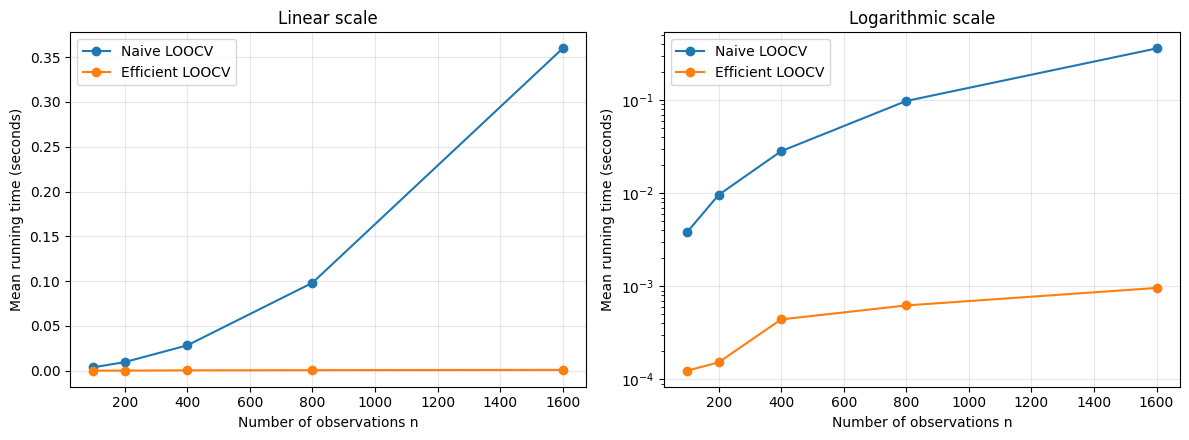

In [23]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5)
)

axes[0].plot(
    ns,
    naive_mean_times,
    marker="o",
    label="Naive LOOCV"
)

axes[0].plot(
    ns,
    efficient_mean_times,
    marker="o",
    label="Efficient LOOCV"
)

axes[0].set_xlabel("Number of observations n")
axes[0].set_ylabel("Mean running time (seconds)")
axes[0].set_title("Linear scale")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    ns,
    naive_mean_times,
    marker="o",
    label="Naive LOOCV"
)

axes[1].plot(
    ns,
    efficient_mean_times,
    marker="o",
    label="Efficient LOOCV"
)

axes[1].set_xlabel("Number of observations n")
axes[1].set_ylabel("Mean running time (seconds)")
axes[1].set_title("Logarithmic scale")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()

plt.savefig(
    "loocv_running_times.pdf",
    bbox_inches="tight"
)

plt.show()